# 2. Machine Learning for Regression

In [144]:
import pandas as pd
import numpy as np
from pathlib import Path

# 2.2 Data Preparation

In [145]:
# Paths
base_path = Path.cwd()
file_path = base_path / "data" / "data.csv"
df = pd.read_csv(file_path)

In [146]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  str    
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   str    
 10  Vehicle Size       11914 non-null  str    
 11  Vehicle Style      11914 non-null  str    
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

In [147]:
# replacing column names with lower caps and spaces with underscore in the column name
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [148]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [149]:
string_columns = df.dtypes[df.dtypes == 'str']
string_columns = list(string_columns.index)

In [150]:
# make column data lower case and replace spaces with '_'
for col in string_columns:#
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [151]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [152]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

# 2.3 Exploratory data analysis

In [153]:
for col in df.columns:
    print(f'{col} : \n')
    print (df[col].unique()[:5])
    print('-'*100)
    print(df[col].nunique())
    print('-'*100)
    print()

make : 

<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
----------------------------------------------------------------------------------------------------
48
----------------------------------------------------------------------------------------------------

model : 

<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
----------------------------------------------------------------------------------------------------
914
----------------------------------------------------------------------------------------------------

year : 

[2011 2012 2013 1992 1993]
----------------------------------------------------------------------------------------------------
28
----------------------------------------------------------------------------------------------------

engine_fuel_type : 

<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',  

In [154]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


### Distribution of Target Variable "msrp" or Price

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

# configures the Matplotlib backend so that all generated figures appear immediately below the code cell that produced them.
%matplotlib inline 

<Axes: xlabel='msrp', ylabel='Count'>

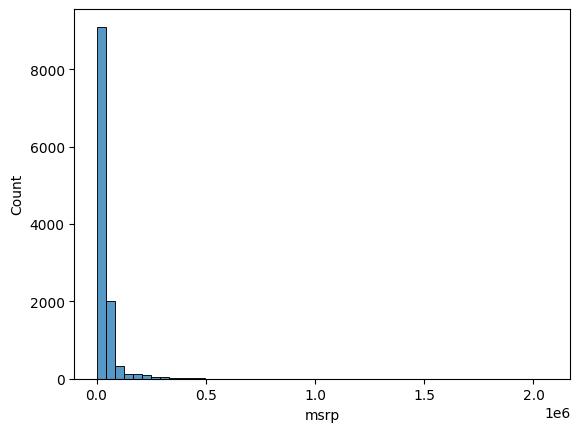

In [156]:
sns.histplot(df.msrp, bins=50)

<Axes: ylabel='msrp'>

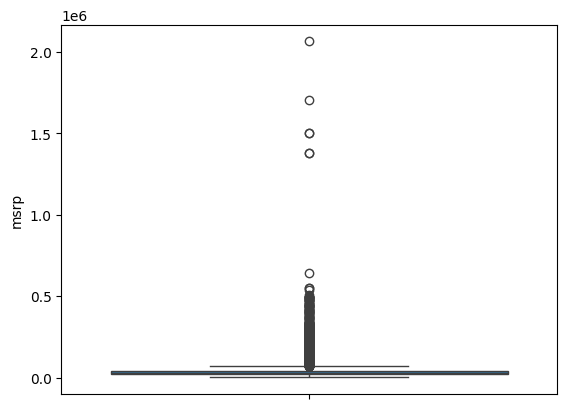

In [157]:
sns.boxplot(df.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

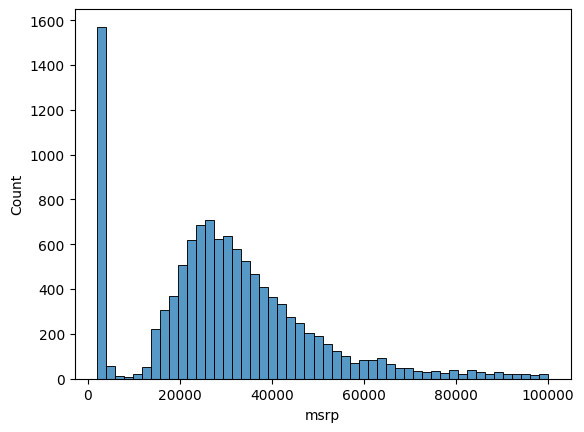

In [158]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

##### This long tail distribution confuses the ML model. To reduce skewness in features with long-tailed distributions, natural logarithm of $\ln(1 + x)$ for every element of msrp is calculated.

In [159]:
# np.log([0, 1, 10, 1000, 100000]) # log 0 produces an error

# fixing log 0 error, add 1 to each value or series
np.log([0 + 1, 1 + 1, 10 + 1, 1000 + 1, 100000 + 1])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [160]:
# same as np.log([0 + 1, 1 + 1, 10 + 1, 1000 + 1, 100000 + 1])
np.log1p([0, 1, 10, 1000, 100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [161]:
price_logs = np.log1p(df.msrp)

##### This gives a bell curved normal distribution aka gaussian distribution ideal for models.

<Axes: xlabel='msrp', ylabel='Count'>

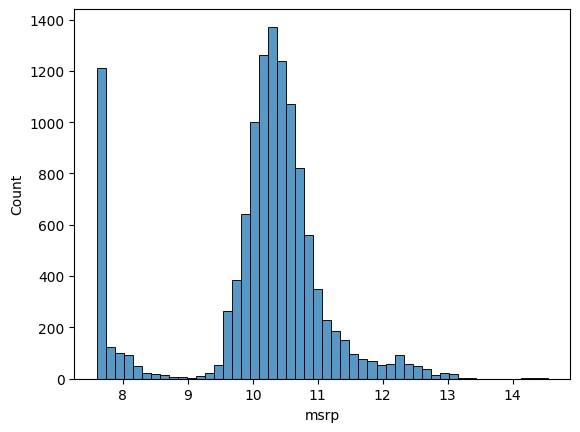

In [162]:
sns.histplot(price_logs, bins=50)

### Missing Values

In [163]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

# 2.4 Setting up the validation Framework

<div style="width:60%; margin-left:40px; font-size:28px;">

| Dataset Split | Percentage | Features | Target |
|---------------|------------|----------|--------|
| Train         | 60%        | $X_{train}$ | $y_{train}$ |
| Validation    | 20%        | $X_{val}$ | $y_{val}$ |
| Test          | 20%        | $X_{test}$ | $y_{test}$ |

</div>

In [164]:
# total records
n =len(df)

# data set split
n_valid = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - sum([n_valid, n_test])

print(f'Total Records : {n}')
print(f'Validation + Test Records Total: {n_train + n_valid + n_test}')

Total Records : 11914
Validation + Test Records Total: 11914


In [165]:
n_train, n_valid, n_test, 

(7150, 2382, 2382)

##### Split the data by number of records.

In [166]:
df_train = df.iloc[:n_train]                 # train split
df_val = df.iloc[n_train:n_train + n_valid]  # validation split
df_test = df.iloc[n_train + n_valid:]        # test split

In [167]:
df_val.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
7150,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,63645
7151,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,22,16,61,63195
7152,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,76650
7153,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,69135
7154,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,65560


In [168]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


##### Some "make" in train df like bmw is missing in validation df. Data should be shuffled.

In [169]:
np.arange(n)

array([    0,     1,     2, ..., 11911, 11912, 11913], shape=(11914,))

In [170]:
index = np.arange(n)

np.random.seed(2)
np.random.shuffle(index)

In [171]:
index

array([2735, 6720, 5878, ..., 6637, 2575, 7336], shape=(11914,))

In [172]:
train_split = index[: n_train]               # 60% for training by index
val_split = index[n_train:n_train + n_valid] # 20 % validation by index
test_split = index[n_train + n_valid:]       # 20% test by index

In [173]:
df_train = df.iloc[train_split] # train split, 60%
df_val = df.iloc[val_split]     # validation split, 20%
df_test = df.iloc[test_split]   # test split, 20%


In [174]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [175]:
# confirmation of number of records in the newly created splits
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [176]:
# reset indices
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

##### Reduce skewness in target variable "msrp" with long-tailed distributions with natural logarithm.

In [177]:
df_train.msrp.values

array([ 14410,  19685,  19795, ...,  34675, 303300,  37820], shape=(7150,))

In [178]:
np.log1p(df_train.msrp.values)

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

In [179]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [180]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

##### Remove target variable from the train, validation and test data partitions

In [181]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

# 2.5 Linear Regression

$$
\large y = w_0 + w_1 x_{1} + w_2 x_{2} + \dots + w_n x_{n}
$$

$$
\text{or}
$$


$$
g(X_{i}) = X_{i}w \approx y
$$

- $X$ : feature matrix  
- $g$ : model (linear regression)  
- $y$ : target variable (price)

In [182]:
# sample one row
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [183]:
columns = ['engine_hp', 'city_mpg', 'popularity']
xi = df_train.loc[10, columns].values
print(xi)

[453.  11.  86.]


##### Simple linear regression function

$$
\large y = w_0 + w_1 x_{1} + w_2 x_{2} + \dots + w_n x_{n}
$$

$$
\text{or}
$$

$$
\large g(x_i) = w_0 + \sum_{j=1}^{n} w_j x_{ij}
$$

In [184]:
# # Arbitrary values
w_0 = 7.17
w = [0.01, 0.04, 0.002]

In [185]:
# linear regression function g(xi)
def linear_regression(xi):
    pred = w_0
    
    n = len(xi)

    for j in range(n):
        pred += w[j] * xi[j]
        
    return pred

In [186]:
y_out = linear_regression(xi)
print(y_out)

12.312


##### Remember Natural Logarithm and its inverse for predicted values.
$$
\large \ln(x+1) = y \quad \Longleftrightarrow \quad x = e^{y} - 1
$$

In [187]:
x_out = np.expm1(y_out)        # inverse of natural logarithm (exponential function) alteranatively np.exp(y_out) - 1
# x_out = np.exp(y_out) - 1
print(x_out)

222347.2221101062


In [188]:
# confirmation of In(x + 1) = y
np.log1p(x_out)

np.float64(12.312)

# 2.6 Linear regression vector form

#### Dot product of a matrix

$$
\large
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
\begin{bmatrix}
e & f \\
g & h
\end{bmatrix}
=
\begin{bmatrix}
ae + bg & af + bh \\
ce + dg & cf + dh
\end{bmatrix}
$$

In [189]:
def dot(xi, w):
    n = len(xi)
    res = 0.0

    for j in range(n):
        # res = res + w[j] * xi[j]   # see below formula
        res += w[j] * xi[j]
    return res
    

$$
\large
g(x_i) =
w_0 +
\begin{bmatrix}
w_1 & w_2 & \dots & w_n
\end{bmatrix}
\begin{bmatrix}
x_{i1} \\
x_{i2} \\
\vdots \\
x_{in}
\end{bmatrix}
$$

$$
\text{or}
$$

$$
\large
g(x_i) = w_0 + \mathbf{w} \mathbf{x}^T_i 
$$

In [190]:
def linear_regression(xi):              
    return w_0 + dot(xi, w)

In [191]:
# merge weights i.e w_0 and [w_1, w_2, ...w_n] list to one vector/list as above in g(xi)
w_new = [w_0] + w
print(w_new)

[7.17, 0.01, 0.04, 0.002]


In [192]:
xi_aug = [1] + list(xi)
xi_aug

[1, np.float64(453.0), np.float64(11.0), np.float64(86.0)]

In [193]:
# linear regression function g(xi)
def linear_regression(xi):    
    # [1, 453.  11.  86.]
    xi = [1] + list(xi)           # the coefficent of w_0 (x_i0) is 1 in formula g(xi)
    return dot(xi, w_new)

In [194]:
linear_regression(xi)

np.float64(12.312)

#### Linear Regression: Vector Form

The prediction vector is the result of the matrix-vector product:

$$\large \mathbf{X}\mathbf{w} = \hat{\mathbf{y}}$$

$$\large \begin{bmatrix} 
1 & x_{1,1} & \dots & x_{1,n} \\ 
1 & x_{2,1} & \dots & x_{2,n} \\ 
\vdots & \vdots & \ddots & \vdots \\ 
1 & x_{m,1} & \dots & x_{m,n} 
\end{bmatrix} 
\begin{bmatrix} w_0 \\ w_1 \\ \vdots \\ w_n \end{bmatrix} = 
\begin{bmatrix} \mathbf{x}_1^\top \mathbf{w} \\ \mathbf{x}_2^\top \mathbf{w} \\ \vdots \\ \mathbf{x}_m^\top \mathbf{w} \end{bmatrix}$$


* **$\large\mathbf{X}$**: Design Matrix $m \times (n+1)$
* **$\large\mathbf{w}$**: Weights Vector $(n+1) \times 1$
* **$\large\hat{\mathbf{y}}$**: Predictions (PRED) $m \times 1$

In [195]:
# Arbitrary values
x1 = [1, 148, 24, 1385]
x2 = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [196]:
def linear_regression(X):
    return X.dot(w_new)

In [197]:
linear_regression(X)

array([12.38 , 13.552, 12.312])

# 2.7 Training a linear regression model

### Linear Regression Normal Equation

The closed-form solution for Linear Regression weights is:
$$
\large
(X^T X)^{-1} X^T X w =  (X^T X)^{-1} X^T y
$$

$$
\large
w = (X^T X)^{-1} X^T y
$$

where:

- ($X$) is the **design matrix** (features)
- ($X^T$) is the **transpose of \(X\)**
- ($y$) is the **target vector**
- ($w$) is the **weight vector**

---

## Gram Matrix

The matrix

$$
\large
G = X^T X
$$

is called the **Gram Matrix**.

### Shape

If the design matrix has shape

$$
\large
X \in \mathbb{R}^{m \times (n+1)}
$$

(where \(m\) is the number of samples and \(n+1\) includes the bias feature),

then the Gram matrix has shape

$$
\large
X^T X \in \mathbb{R}^{(n+1) \times (n+1)}
$$

---

### Element Definition

Each element of the Gram matrix is an inner product between feature columns:

$$
\large
G_{ij} = x_i^T x_j
$$

---

### Intuition

The Gram matrix measures **similarity between features**:

- Large values → features are strongly correlated
- Small values → features are weakly correlated

---

### Summary

1. Build the design matrix ($X$)
2. Compute the Gram matrix ($X^T X$)
3. Invert the Gram matrix ($(X^T X)^{-1}$)
4. Multiply by ($X^T y$)

$$
\large
w = (X^T X)^{-1} X^T y
$$

This gives the **optimal weights that minimize squared error in Linear Regression**.

In [198]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38, 54, 185],
    [142, 25, 431],
    [453, 31, 86]
    
    
]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [199]:
# Arbitrary values
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

In [200]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0]) # Bias term vector values
    X = np.column_stack([ones, X])  # adds 1's to the 1st column of X

    # Gram Matrix
    
    # XTX_inv.dot(XTX).round(1) # should give an identity matrix
    
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.pinv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y) # Calculation of the weight formula

    w_0 = w_full[0] # bias term
    w = w_full[1:]  # weights

    return w_0, w

In [201]:
train_linear_regression(X, y)

(np.float64(25844.75405561282),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

# 2.8 Car price baseline model

In [202]:
# numeric columns only
df_train.select_dtypes(include='number').dtypes

year                  int64
engine_hp           float64
engine_cylinders    float64
number_of_doors     float64
highway_mpg           int64
city_mpg              int64
popularity            int64
dtype: object

In [203]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [204]:
# subset of numeric columns used
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']


In [205]:
df_train[base].isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [206]:
X_train = df_train[base].values

In [207]:
X_train = df_train[base].fillna(0).isnull().sum()
X_train

engine_hp           0
engine_cylinders    0
highway_mpg         0
city_mpg            0
popularity          0
dtype: int64

In [208]:
X_train = df_train[base].fillna(0).values
X_train

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]], shape=(7150, 5))

In [209]:
w_0, w = train_linear_regression(X_train, y_train)

In [210]:
# prediction results
y_pred = w_0 + X_train.dot(w)

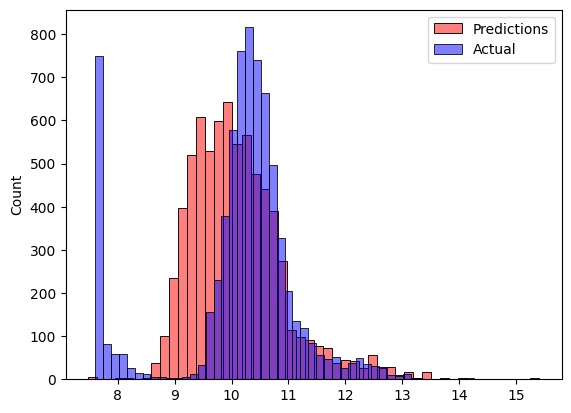

In [211]:
sns.histplot(y_pred, color='red',alpha=0.5, bins=50, label='Predictions')
sns.histplot(y_train, color='blue',alpha=0.5,  bins=50, label='Actual')
plt.legend()

# 2.9 RMSE

### Root Mean Squared Error (RMSE)

The **Root Mean Squared Error** measures the average magnitude of prediction errors in a regression model.

$$
\large
RMSE = \sqrt{\frac{1}{m} \sum_{i=1}^{m} \left(g(x_i) - y_i \right)^2}
$$

---

## Variables

- $m$ : Number of observations (samples) in the dataset  
- $x_i$ : Feature vector for the $i^{th}$ observation  
- $g(x_i)$ : Model prediction for $x_i$  
- $y_i$ : Actual (true) target value for the $i^{th}$ observation  
- $g(x_i) - y_i$ : Prediction error (residual)  
- $(g(x_i) - y_i)^2$ : Squared error for observation $i$ 

---

## Interpretation

RMSE computes the square root of the **average squared difference between predictions and actual values**.

- Smaller RMSE → Better model fit  
- Larger RMSE → Predictions are further from the true values

RMSE has the **same units as the target variable**, which makes it easier to interpret compared to MSE.

In [212]:
# function to calculate rmse
def rmse(y, y_pred): 
    se = (y_pred - y) ** 2
    mse = se.mean() 

    return np.sqrt(mse)

In [213]:
rmse(y_train, y_pred)

np.float64(0.7554192603920132)

# 2.10 Validating the Model

In [214]:
def prepare_X(df):  
    df_num = df[base] # subset of numeric columns used
    X = df_num.fillna(0).values # missing value replace with zeros
    
    return X

In [215]:
# trained modelweight
X_train = prepare_X(df_train)
w_0, w = train_linear_regression(X_train, y_train)

# test the trained model weight with validation set
X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)

# measure the error of predic validation values vs actual validation 
rmse(y_val, y_pred)

np.float64(0.7616530991308951)

# 2.11 Simple feature Engineering

In [216]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 7150 entries, 0 to 7149
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               7150 non-null   str    
 1   model              7150 non-null   str    
 2   year               7150 non-null   int64  
 3   engine_fuel_type   7149 non-null   str    
 4   engine_hp          7110 non-null   float64
 5   engine_cylinders   7136 non-null   float64
 6   transmission_type  7150 non-null   str    
 7   driven_wheels      7150 non-null   str    
 8   number_of_doors    7144 non-null   float64
 9   market_category    4899 non-null   str    
 10  vehicle_size       7150 non-null   str    
 11  vehicle_style      7150 non-null   str    
 12  highway_mpg        7150 non-null   int64  
 13  city_mpg           7150 non-null   int64  
 14  popularity         7150 non-null   int64  
dtypes: float64(3), int64(4), str(8)
memory usage: 838.0 KB


In [217]:
# Age of cars
df_train.year.max() - df_train.year

0        9
1        5
2        1
3       26
4        0
        ..
7145     2
7146     2
7147     2
7148     3
7149     0
Name: year, Length: 7150, dtype: int64

In [218]:
def prepare_X(df):
    df = df.copy()
    # Age of cars
    df['age'] = df.year.max() - df.year
    features = base + ['age']
    
    df_num = df[features] # subset of numeric columns used
    X = df_num.fillna(0).values # missing value replace with zeros
    
    return X

In [222]:
# trained modelweight
X_train = prepare_X(df_train)
w_0, w = train_linear_regression(X_train, y_train)

# test the trained model weight with validation set
X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)

# measure the error of predic validation values vs actual validation 
rmse(y_val, y_pred)

np.float64(0.517205546106432)

In [221]:
X_train

array([[1.480e+02, 4.000e+00, 3.300e+01, 2.400e+01, 1.385e+03, 9.000e+00],
       [1.320e+02, 4.000e+00, 3.200e+01, 2.500e+01, 2.031e+03, 5.000e+00],
       [1.480e+02, 4.000e+00, 3.700e+01, 2.800e+01, 6.400e+02, 1.000e+00],
       ...,
       [2.850e+02, 6.000e+00, 2.200e+01, 1.700e+01, 5.490e+02, 2.000e+00],
       [5.630e+02, 1.200e+01, 2.100e+01, 1.300e+01, 8.600e+01, 3.000e+00],
       [2.000e+02, 4.000e+00, 3.100e+01, 2.200e+01, 8.730e+02, 0.000e+00]],
      shape=(7150, 6))

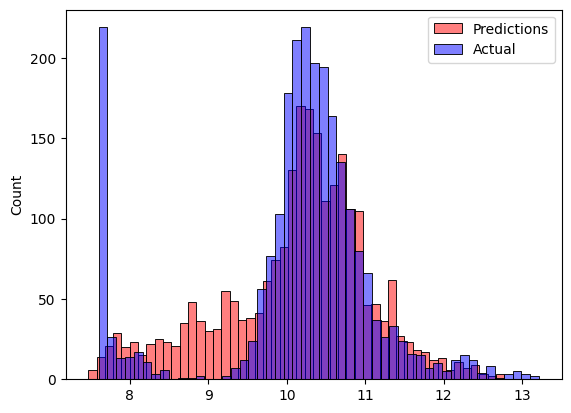

In [224]:
sns.histplot(y_pred, color='red',alpha=0.5, bins=50, label='Predictions')
sns.histplot(y_val, color='blue',alpha=0.5,  bins=50, label='Actual')
plt.legend()